In [1]:
import pandas as pd
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
import warnings
import seaborn
from IPython.display import Markdown

set_matplotlib_formats('svg')

families_timedep = [
    'conficker',
    'corebot',
    'cryptolocker',
    'emotet',
    'gozi',
    'matsnu',
    'murofet',
    'necurs',
    'nymaim',
    'padcrypt',
    'qadars',
    'suppobox',
    'symmi'
]
families_timeindep = [
    'dircrypt',
    'fobber',
    'kraken',
    'pushdo',
    'pykspa',
    'ramdo',
    'ramnit',
    'ranbyus',
    'rovnix',
    'simda',
    'tinba',
    'vawtrak'
]

families = families_timedep + families_timeindep

DF_DAC_LSTM = pd.read_pickle('merged.pickle') # 28s

In [ ]:


DF = None
for nn in ['none', 'icann', 'tld', 'private']:

    display(Markdown(f"# {nn}"))

    col_tp = f'tp_{nn}'
    col_tpr = f'tpr_{nn}'

    DF_DAC_LSTM[col_tp] = (DF_DAC_LSTM[f'eps_{nn}'] > 0.5) & (DF_DAC_LSTM['tranco_rank'].isna())

    dfg = DF_DAC_LSTM[[col_tp, 'year', 'family', 'icann', 'private']].groupby(['year', 'family']).aggregate({
        col_tp: ['count', 'sum'],
        'icann': lambda x: (~x.isna()).sum(),
        'private': lambda x: (~x.isna()).sum()
    })

    dfg[col_tpr] = dfg[col_tp, 'sum'] / dfg[col_tp, 'count']

    dfg = dfg.reset_index()
    
    year = dfg[['family', 'year']].groupby('family').aggregate(['min', 'max', lambda x: x.isna().sum()])
    year.columns = ['yearmin', 'yearmax', 'isna']
    year = year.astype(int)
    suffix = dfg[['family', 'icann', 'private']].groupby('family').sum()
    suffix.columns = [ 'icann', 'private' ]
    tpr = dfg[['family', col_tpr]].groupby('family').aggregate(['min', 'max', 'std', 'mean'])
    with warnings.catch_warnings():
        tpr = tpr.droplevel([0,1], axis=1)
        pass

    tmp = year.join(suffix).join(tpr)
    tmp['nn'] = nn
    DF = tmp if DF is None else pd.concat([DF, tmp])

    pass

    """output is a DF with family, yearmin, yearmax, nn, 
    """
# 1m 22.5s

In [8]:
DF.to_csv("grouping by family.csv")
DF

,yearmin,yearmax,isna,icann,private,min,max,std,mean,nn
family,,,,,,,,,,
bamital,2010,2019,0,0,0,0.752608,0.761934,0.002951,0.757342,none
bedep,2015,2018,0,0,0,0.971910,0.981153,0.004621,0.974221,none
blackhole,2012,2019,0,0,0,0.994521,0.994550,0.000011,0.994528,none
ccleaner,2017,2019,0,0,0,0.000000,0.071429,0.041239,0.023810,none
chinad,2012,2019,0,0,0,0.995387,0.996062,0.000215,0.995627,none
...,...,...,...,...,...,...,...,...,...,...
ud2,2015,2019,0,0,0,0.346281,0.500000,0.064809,0.387862,private
vidro,2010,2019,0,0,50500,0.918269,0.927308,0.002856,0.921372,private
virut,2013,2019,0,0,0,0.543978,0.544672,0.000280,0.544302,private


In [ ]:
import warnings
import seaborn
from IPython.display import Markdown

DF_GRP = None
for nn in ['none', 'icann', 'tld', 'private']:

    DF_DAC_LSTM['tp'] = (DF_DAC_LSTM[f'eps_{nn}'] > 0.5) & (DF_DAC_LSTM['tranco_rank'].isna())

    dfg = DF_DAC_LSTM[['tp', 'year', 'family', 'icann', 'private']].groupby(['year', 'family']).aggregate({
        'tp': ['count', 'sum'],
        'icann': lambda x: (~x.isna()).sum(),
        'private': lambda x: (~x.isna()).sum()
    })

    dfg['tpr'] = dfg['tp', 'sum'] / dfg['tp', 'count']

    dfg = dfg.reset_index()
    dfg['nn'] = nn

    DF_GRP = dfg if DF_GRP is None else pd.concat([DF_GRP, dfg])

    pass

DF_GRP

# 1m9s

# none

# icann

# tld

# private

year       family       tp             icann  private       tpr  \
                            count      sum <lambda> <lambda>             
0    1970.0       necurs   178308    79248        0        0  0.444444   
1    2006.0       szribi       16       11        0        0  0.687500   
2    2007.0       szribi     1952     1582        0        0  0.810451   
3    2008.0    conficker    76500    57570        0        0  0.752549   
4    2008.0       szribi     1952     1608        0        0  0.823770   
..      ...          ...      ...      ...      ...      ...       ...   
347  2019.0          ud2     1220      434        0        0  0.355738   
348  2019.0        vidro    16200    14907        0     5400  0.920185   
349  2019.0        virut  3670000  1997612        0        0  0.544308   
350  2019.0           wd    29360    14470        0        0  0.492847   
351  2019.0  xshellghost       14       13        0        0  0.928571   

          nn  
              
0       none  
1       none  
2       none  
3       none  
4       none  
..       ...  
347  private  
348  private  
349  private  
350  private  
351  private  

[1408 rows x 8 columns]

In [208]:

from sqlalchemy import column


S = DF_DAC_LSTM.value_counts(['family', 'tld']).reset_index()
S2 = DF_DAC_LSTM.value_counts('family').reset_index()
S = S.merge(S2, on='family')
S['count'] = S['count_x'] / S['count_y']
DF_DAC_TLD_ALL = S.drop(columns=['count_x','count_y']).set_index(['family', 'tld'])


S = DF_TRAIN.rename(columns={'class': 'family'}).value_counts(['family', 'tld']).reset_index()
S2 = DF_TRAIN.rename(columns={'class': 'family'}).value_counts('family').reset_index()
S = S.merge(S2, on='family')
S['count'] = S['count_x'] / S['count_y']
DF_TRAIN_TLD_ALL = S.drop(columns=['count_x', 'count_y']).set_index(['family', 'tld'])

DF_TLD = DF_DAC_TLD_ALL.join(DF_TRAIN_TLD_ALL, lsuffix=' dac', rsuffix=' train')
DF_TLD = DF_TLD.sort_index().reset_index(level=1)
DF_TLD = DF_TLD.loc[DF_TLD.index.intersection(families)]

# DF_TLD

In [258]:
DF_TLD['na dac'] = DF_TLD['count dac'].isna()
DF_TLD['na train'] = DF_TLD['count train'].isna()

DF_TLD['diff'] = (DF_TLD['count dac'].fillna(0) - DF_TLD['count train'].fillna(0)).round(3) * 100

DF_TLD = DF_TLD.reset_index().groupby('family').agg({ 'diff': 'mean', 'na dac': 'sum', 'na train': 'sum' }).round(2).sort_values(by='diff')

print(DF_TLD.style.format(precision=2).to_latex())

\begin{tabular}{lrrr}
 & diff & na dac & na train \\
family &  &  &  \\
corebot & -0.01 & 0 & 6 \\
ranbyus & -0.01 & 0 & 1 \\
vawtrak & -0.00 & 0 & 0 \\
cryptolocker & 0.00 & 0 & 0 \\
dircrypt & 0.00 & 0 & 0 \\
emotet & 0.00 & 0 & 0 \\
fobber & 0.00 & 0 & 0 \\
gozi & 0.00 & 0 & 21 \\
matsnu & 0.00 & 0 & 0 \\
symmi & 0.00 & 0 & 0 \\
necurs & -0.00 & 0 & 1 \\
suppobox & 0.00 & 0 & 0 \\
simda & 0.00 & 0 & 0 \\
ramdo & 0.00 & 0 & 0 \\
qadars & 0.00 & 0 & 0 \\
padcrypt & 0.01 & 0 & 0 \\
tinba & 0.01 & 0 & 6 \\
rovnix & 0.02 & 0 & 0 \\
ramnit & 0.03 & 0 & 0 \\
murofet & 2.22 & 0 & 0 \\
pykspa & 7.88 & 0 & 0 \\
nymaim & 8.90 & 0 & 0 \\
conficker & 12.25 & 0 & 0 \\
pushdo & 50.00 & 0 & 2 \\
\end{tabular}



In [21]:
DF_GRP.columns = [ 'year', 'family', 'tp count', 'tp sum', 'icann', 'private', 'tpr', 'nn']
# DF_GRP.to_csv("grouping by year, family.csv")
DF_GRP
DF_GRP.groupby('family').agg({ 'tp count': 'sum'})

,tp count
family,
bamital,1389024
bedep,145864
blackhole,23392
ccleaner,160
chinad,2995200
conficker,8338000
corebot,2851680
cryptolocker,10232000
diamondfox,58560


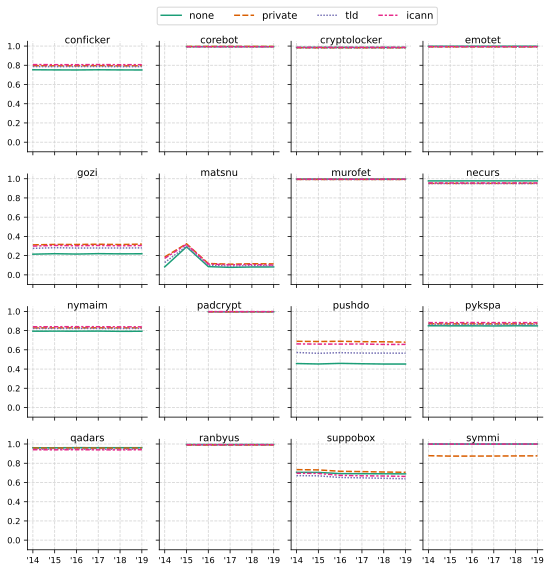

In [28]:

%matplotlib inline
from gzip import _PaddedFile
from matplotlib import pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

filter_families = DF_GRP.family.apply(lambda x: x in families)

filter_years = DF_GRP['year'] >= 2014

filter_families_years = filter_families & filter_years

g = seaborn.relplot(
    DF_GRP[filter_families_years].sort_values(by='family'),
    x='year', y='tpr',
    col='family',
    hue='nn',
    style='nn',
    kind='line',
    col_wrap=4,
    aspect=1,

    height=2,
    # palette=seaborn.color_palette("blend:#000,#77205C,#97507C,#E7C6BF", 4)
    palette=seaborn.color_palette('Dark2', 4)
    # legend=False
)

g.legend.remove()
nrows = g.axes.shape[0]

[ g.axes[i].set_title(g.axes[i].title.get_text().split('= ')[1], size="medium", y=1, pad=-2) for i in range(nrows) ]
[ g.axes[i].set_ylim(-0.1, 1.05) for i in range(nrows) ]
[ g.axes[i].grid(True, axis='both', linestyle='--', color='lightgray') for i in range(nrows) ]
[ g.axes[i].set_xticks([2014, 2015, 2016, 2017, 2018, 2019], ['\'14','\'15','\'16','\'17','\'18','\'19'], size='small') for i in range(nrows) ]
[ g.axes[i].set_ylabel('') for i in range(nrows) ]
[ g.axes[i].set_xlabel('') for i in range(nrows) ]
[ g.axes[i].tick_params(labelsize='small') for i in range(nrows) ]



plt.gcf().legend(loc='upper center', ncols=4, bbox_to_anchor=(0.5, 1.025))
plt.gcf().subplots_adjust(hspace=0.2, wspace=0.1)

plt.gcf().savefig(f'plot.pdf', bbox_inches='tight')

In [220]:
tmp = DF_GRP.groupby(['family', 'nn']).agg({'tpr': 'mean'}).unstack(1)

tmp.loc[tmp.index.intersection(families)]

tpr                              
nn               icann      none   private       tld
family                                              
conficker     0.806644  0.752383  0.794626  0.786401
corebot       0.993131  0.994374  0.996115  0.993336
cryptolocker  0.987055  0.986190  0.982317  0.981975
emotet        0.994630  0.998364  0.991709  0.992739
gozi          0.302960  0.216721  0.315252  0.278374
matsnu        0.162547  0.116180  0.201822  0.130775
murofet       0.995536  0.995931  0.992172  0.992519
necurs        0.836419  0.910903  0.832423  0.831292
nymaim        0.840466  0.794159  0.828571  0.822504
padcrypt      0.997589  0.996073  0.996259  0.996922
pushdo        0.659725  0.455806  0.686538  0.569751
pykspa        0.883230  0.849702  0.870681  0.864384
qadars        0.940024  0.961542  0.957657  0.946438
ranbyus       0.993689  0.995011  0.990170  0.991605
suppobox      0.682777  0.698800  0.723105  0.659189
symmi         0.999319  0.999976  0.876051  0.999520

In [280]:

dfg = DF_GRP.copy()

year = dfg[['family', 'year']].groupby('family').aggregate(['min', 'max', lambda x: x.isna().sum()])
year.columns = ['min', 'max', 'isna']
year.columns = pd.MultiIndex.from_product([['year'], year.columns])
year = year.astype(int)

suffix = dfg[['family', 'icann', 'private']].groupby('family').sum()
suffix.columns = pd.MultiIndex.from_product([['sfx'], ['icann', 'private']])

tpr = dfg[['family', 'tpr', 'nn']].groupby(['family', 'nn']).agg({'tpr': 'mean'}).unstack(1)
DF_compare = year.join(suffix).join(tpr)
# tpr
DF_compare

year                 sfx                tpr            \
                        min   max isna    icann  private     icann      none   
family                                                                         
bamital                2010  2019    0        0        0  0.172567  0.757342   
bedep                  2015  2018    0        0        0  0.972704  0.974221   
blackhole              2012  2019    0        0        0  0.993160  0.994528   
ccleaner               2017  2019    0        0        0  0.126374  0.023810   
chinad                 2012  2019    0        0        0  0.991431  0.995627   
conficker              2008  2019    0        0        0  0.806644  0.752383   
corebot                2015  2019    0        0   658080  0.993131  0.994374   
cryptolocker           2013  2019    0  1463176        0  0.987055  0.986190   
diamondfox             2016  2019    0        0        0  0.106372  0.098553   
dyre                   2014  2019    0        0        0  0.554611  0.924021   
ekforward              2015  2019    0        0        0  0.019704  0.035574   
emotet                 2014  2019    0        0        0  0.994630  0.998364   
gameover               2014  2019    0        0        0  0.999061  0.999589   
gameover_p2p_a37c4dbb  2010  2019    0        0        0  0.999808  0.999767   
gozi                   2010  2019    0        0        0  0.302960  0.216721   
goznym                 2016  2017    0        0        0  0.833020  0.671498   
infy                   2014  2019    0        0        0  0.018823  0.075353   
locky                  2015  2019    0        0        0  0.943970  0.894973   
madmax                 2015  2019    0        0        0  0.839583  0.889583   
matsnu                 2013  2019    0        0        0  0.162547  0.116180   
mirai                  2016  2019    0        0        0  0.968108  0.789476   
modpack                2015  2019    0        0        0  0.423049  0.439928   
monerominer            2018  2019    0        0        0  0.217025  0.337687   
murofet                2010  2019    0        0        0  0.995536  0.995931   
murofetweekly          2010  2019    0        0        0  0.999742  0.999972   
mydoom                 2010  2019    0        0        0  0.882630  0.864560   
necurs                 1970  2019    0        0        0  0.836419  0.910903   
nymaim                 2012  2019    0        0        0  0.840466  0.794159   
nymaim2                2018  2019    0        0        0  0.745545  0.857514   
oderoor                2013  2019    0        0    22032  0.937289  0.940371   
padcrypt               2016  2019    0    61852        0  0.997589  0.996073   
pandabanker            2016  2019    0        0        0  0.115459  0.667406   
pitou                  2015  2019    0        0        0  0.369383  0.316179   
proslikefan            2015  2019    0        0        0  0.858768  0.795683   
pushdo                 2012  2019    0        0        0  0.659725  0.455806   
pykspa                 2013  2019    0        0        0  0.883230  0.849702   
pykspa2                2019  2019    0        0        0  0.969681  0.983511   
qadars                 2013  2019    0        0        0  0.940024  0.961542   
qakbot                 2013  2019    0        0        0  0.984119  0.975973   
qsnatch                2019  2019    0  1714044   185844  0.088645  0.192658   
ranbyus                2015  2019    0        0        0  0.993689  0.995011   
sisron                 2012  2019    0        0        0  1.000000  1.000000   
sphinx                 2016  2019    0        0        0  0.994590  0.992620   
suppobox               2013  2019    0        0        0  0.682777  0.698800   
sutra                  2011  2019    0        0        0  0.664504  0.913956   
symmi                  2014  2019    0        0  1156736  0.999319  0.999976   
szribi                 2006  2019    0        0        0  0.907235  0.820281   
tempedrevetdd          

In [286]:


nns = ['none', 'tld', 'icann', 'private']

_df = DF_compare.loc[DF_compare.index.intersection(families)]
# _df = DF_compare.loc[DF_compare.index.difference(families)]

for nn in nns:
    nns2 = [ _ for _ in nns if _ != nn]
    for nn2 in nns2:
        _df[(nn, nn2)] = (_df['tpr', nn] - _df['tpr', nn2])
        pass
    _df[(nn, 'mean')] = _df[[ (nn, nn2) for nn2 in nns2 ]].mean(axis=1)
    pass

_df[('mean', 'mean')] = _df[[('none', 'mean'), ('tld', 'mean'), ('icann', 'mean'), ('private', 'mean')]].mean(axis=1)

_df[[('sfx', 'icann'), ('sfx', 'private')]] = _df[[('sfx', 'icann'), ('sfx', 'private')]].astype(int)

_df = _df.sort_values(by=('mean', 'mean'))

tmp = DF_TLD.copy()
tmp.columns = pd.MultiIndex.from_product([['tld'], tmp.columns])
_df = _df.join(tmp)

mean = _df.mean()
max = _df.max()
min = _df.min()

_df.loc['min'] = min
_df.loc['max'] = max
_df.loc['mean'] = mean

metrics = [
    # ('tld',     'diff'), ('tld',   'na dac'), ('tld', 'na train'),
    ('none', 'tld'),     ('none', 'icann'),    ('none', 'private'),
    ('none', 'mean'),    ('tld', 'none'),      ('tld', 'icann'),
    ('tld', 'private'),  ('tld', 'mean'),      ('icann', 'none'),
    ('icann', 'tld'),    ('icann', 'private'), ('icann', 'mean'),
    ('private', 'none'), ('private', 'tld'), ('private', 'icann'),
    ('private', 'mean')
    # , ('mean', 'mean')
]

_df[metrics] = _df[metrics].round(3) * 100

_df = _df[[
    ('tld',     'diff'), ('tld',   'na dac'), ('tld', 'na train'),
    ('none', 'tld'),     ('none', 'icann'),    ('none', 'private'),
    ('tld', 'none'),      ('tld', 'icann'),    ('tld', 'private'),  
    ('icann', 'none'),   ('icann', 'tld'),    ('icann', 'private'), 
    ('private', 'none'), ('private', 'tld'), ('private', 'icann')
]]

_df.columns = pd.MultiIndex.from_tuples(_df.columns)

print(_df.style.format(precision=1).to_latex())


\begin{tabular}{lrrrrrrrrrrrrrrr}
 & \multicolumn{3}{r}{tld} & \multicolumn{3}{r}{none} & \multicolumn{3}{r}{tld} & \multicolumn{3}{r}{icann} & \multicolumn{3}{r}{private} \\
 & diff & na dac & na train & tld & icann & private & none & icann & private & none & tld & private & none & tld & icann \\
family &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
symmi & 0.0 & 0.0 & 0.0 & 0.0 & 0.1 & 12.4 & -0.0 & 0.0 & 12.3 & -0.1 & -0.0 & 12.3 & -12.4 & -12.3 & -12.3 \\
necurs & -0.0 & 0.0 & 1.0 & 8.0 & 7.4 & 7.8 & -8.0 & -0.5 & -0.1 & -7.4 & 0.5 & 0.4 & -7.8 & 0.1 & -0.4 \\
pykspa & 7.9 & 0.0 & 0.0 & -1.5 & -3.4 & -2.1 & 1.5 & -1.9 & -0.6 & 3.4 & 1.9 & 1.3 & 2.1 & 0.6 & -1.3 \\
nymaim & 8.9 & 0.0 & 0.0 & -2.8 & -4.6 & -3.4 & 2.8 & -1.8 & -0.6 & 4.6 & 1.8 & 1.2 & 3.4 & 0.6 & -1.2 \\
murofet & 2.2 & 0.0 & 0.0 & 0.3 & 0.0 & 0.4 & -0.3 & -0.3 & 0.0 & -0.0 & 0.3 & 0.3 & -0.4 & -0.0 & -0.3 \\
padcrypt & 0.0 & 0.0 & 0.0 & -0.1 & -0.2 & -0.0 & 0.1 & -0.1 & 0.1 & 0.2 & 0.1 & 0.1 & 0.0 & -0.1 & -0.1 \\
c

In [68]:
from pandas import value_counts


DF_TRAIN = pd.read_csv('/Users/princio/Repo/princio/malware-detection-predict-file/scripts/lstm/training/training_0.csv')

DF_TRAIN_GRP = None
for nn in ['none', 'icann', 'tld', 'private']:

    DF_TRAIN['tp'] = (DF_TRAIN[f'eps_{nn}'] > 0.5)

    dfg = DF_TRAIN[['tp', 'class', 'icann', 'private']].groupby('class').aggregate({
        'tp': ['count', 'sum'],
        'icann': lambda x: (~x.isna()).sum(),
        'private': lambda x: (~x.isna()).sum()
    })

    dfg['tpr'] = dfg['tp', 'sum'] / dfg['tp', 'count']

    dfg = dfg.reset_index()
    dfg['nn'] = nn

    DF_TRAIN_GRP = dfg if DF_TRAIN_GRP is None else pd.concat([DF_TRAIN_GRP, dfg])

    pass

DF_TRAIN_GRP.columns = [ 'class', 'tp count', 'tp sum', 'icann', 'private', 'tpr', 'nn' ]

DF_TRP = DF_TRAIN_GRP[['class', 'tpr', 'nn']].pivot(index='class', columns='nn', values='tpr')

train_tpr = DF_TRP.to_dict()